In [1]:
# Task 1: Bank Term Deposit Subscription Prediction

# OBJECTIVE:
# Predict whether a bank customer will subscribe to a term deposit.

# TOOLS USED:
# pandas, scikit-learn, matplotlib, seaborn, shap

# DATASET:
# Fetched using ucimlrepo (ID: 222) — UCI Bank Marketing

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, f1_score
import shap
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Step 1: Load Dataset
data = fetch_ucirepo(id=222)
X = data.data.features.copy()
y = data.data.targets.copy()
df = X.copy()
df['y'] = y

In [3]:
# Step 2: Exploratory Data Analysis (EDA)
print("\n--- Dataset Info ---")
df.info()
print("\n--- Summary Statistics ---")
print(df.describe(include='all'))


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

--- Summary Statistics ---
           


--- Target Distribution ---
y
no     39922
yes     5289
Name: count, dtype: int64


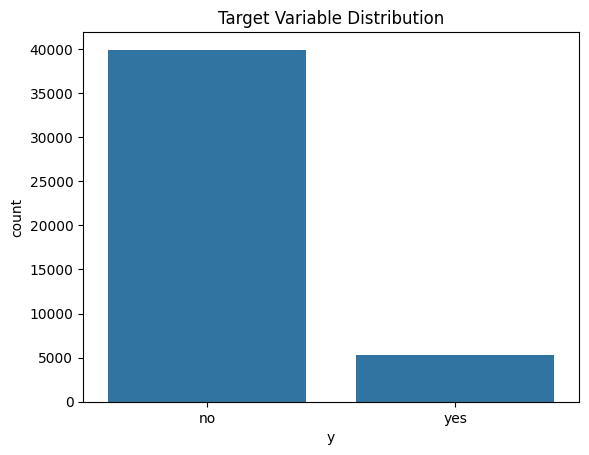

In [4]:
print("\n--- Target Distribution ---")
print(df['y'].value_counts())
sns.countplot(data=df, x='y')
plt.title('Target Variable Distribution')
plt.show()

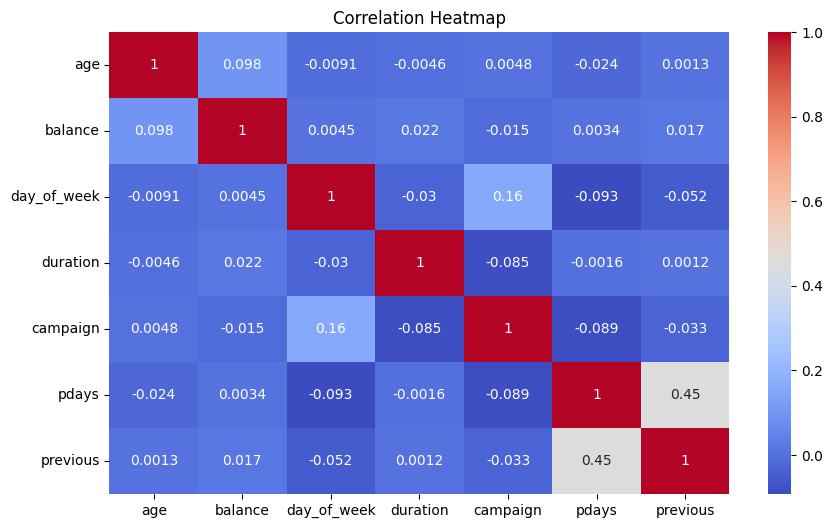

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [6]:
print("\n--- Missing Value Count ---")
print(df.isnull().sum())


--- Missing Value Count ---
age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64


In [7]:
# Step 3: Data Cleaning
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna('unknown', inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

df['target'] = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(columns=['y', 'target'])
y = df['target']

In [8]:
# Step 4: One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

In [9]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, stratify=y, random_state=42)

# Step 6: Train Models
log_model = LogisticRegression(max_iter=2000)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
def print_metrics(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{name} Evaluation")
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    return y_pred, y_prob


def show_visuals(y_pred, y_prob, name):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    RocCurveDisplay.from_predictions(y_test, y_prob)
    plt.title(f"{name} - ROC Curve")
    plt.show()


Logistic Regression Evaluation
F1 Score: 0.4560975609756098
ROC-AUC: 0.9038039187370458
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



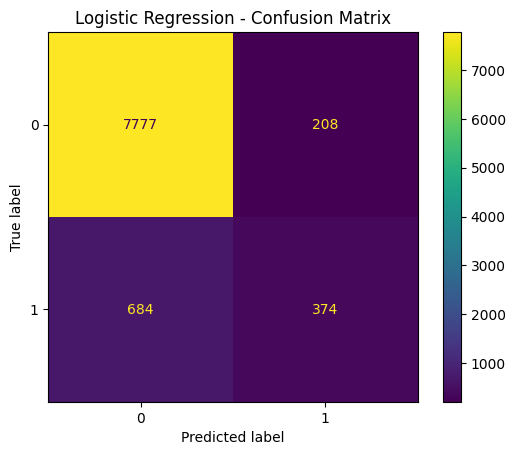

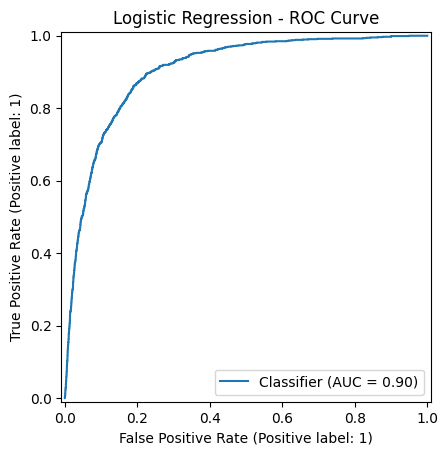

In [11]:
# Logistic Regression
y_pred_log, y_prob_log = print_metrics(log_model, "Logistic Regression")
show_visuals(y_pred_log, y_prob_log, "Logistic Regression")


Random Forest Evaluation
F1 Score: 0.48931116389548696
ROC-AUC: 0.9272173250174891
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.66      0.39      0.49      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.68      0.72      9043
weighted avg       0.89      0.90      0.89      9043



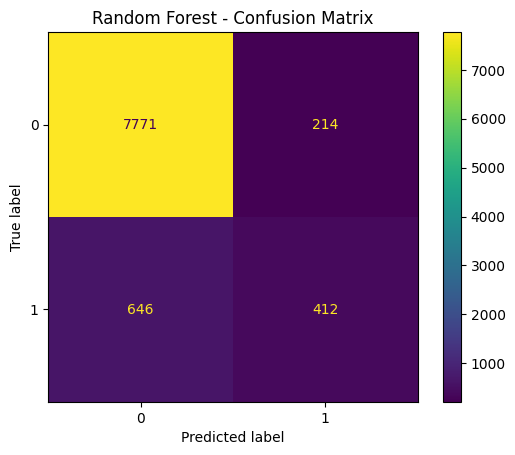

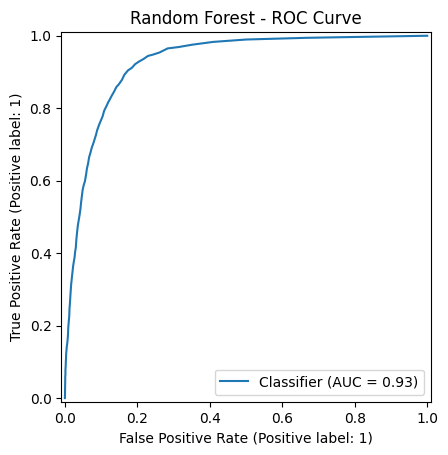

In [12]:
# Random Forest
y_pred_rf, y_prob_rf = print_metrics(rf_model, "Random Forest")
show_visuals(y_pred_rf, y_prob_rf, "Random Forest")

In [ ]:
# Step 8: SHAP Explanations
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[1], X_test, plot_type='bar')

for i in range(5):
    print(f"\nSHAP Explanation for Sample {i+1}:")
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[1][i],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[i],
        feature_names=X_test.columns.tolist()
    ))
